In [1]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("../../data/narc_data/proposaldata.csv", index_col=0 )

In [6]:
df = df.drop(columns = ('palika'), axis = 1)

In [13]:
df.columns

Index(['ph', 'organic_matter', 'total_nitrogen', 'potassium', 'p2o5', 'boron',
       'zinc', 'sand', 'clay', 'slit', 'parentsoil', 'crop', 'variety',
       'UREA1', 'UREA2', 'UREA3', 'DAP', 'MOP', 'organic', 'boron_fert'],
      dtype='object')

In [8]:
df.describe()

,ph,organic_matter,total_nitrogen,potassium,p2o5,boron,zinc,sand,clay,slit,parentsoil,crop,variety,UREA1,UREA2,UREA3,DAP,MOP,organic,boron_fert
count,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000,697415.000000
mean,5.903652,3.125364,0.170008,221.775223,74.264925,0.864778,1.771412,42.704977,21.072776,36.765728,4.383065,0.800000,0.600000,1.360639,2.420701,2.420701,2.723631,2.424694,7.600000,1.300000
std,0.280562,0.680323,0.073516,59.476061,36.898781,0.158689,0.312970,9.150736,5.958532,6.669086,2.483262,0.748332,0.489898,0.785646,0.739324,0.739324,1.091248,0.676219,1.959593,0.244949
min,4.590000,0.940000,0.050000,58.420000,16.770000,0.270000,0.880000,15.420000,4.870000,11.120000,0.000000,0.000000,0.000000,-0.970000,0.600000,0.600000,0.540000,0.420000,6.000000,1.000000
25%,5.700000,2.800000,0.140000,183.380000,49.550000,0.740000,1.550000,37.180000,16.910000,33.570000,2.000000,0.000000,0.000000,0.970000,1.810000,1.810000,1.740000,1.670000,6.000000,1.000000
50%,5.930000,3.110000,0.160000,222.450000,62.090000,0.900000,1.730000,41.070000,21.130000,37.540000,5.000000,1.000000,1.000000,1.260000,2.420000,2.420000,2.890000,2.230000,6.000000,1.500000
75%,6.090000,3.400000,0.180000,255.390000,89.360000,0.980000,1.960000,45.920000,25.190000,40.920000,7.000000,1.000000,1.000000,1.770000,2.900000,2.900000,3.620000,3.340000,10.000000,1.500000
max,7.200000,8.140000,1.010000,661.910000,460.340000,2.400000,4.660000,83.160000,41.270000,70.400000,7.000000,2.000000,1.000000,3.270000,3.620000,3.620000,4.340000,3.340000,10.000000,1.500000


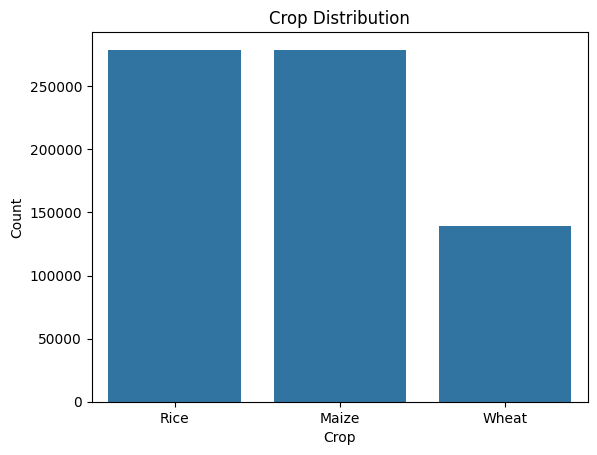

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the countplot
sns.countplot(data=df, x='crop')

# Manually set the tick labels based on your encoding
plt.xticks(ticks=[0, 1, 2], labels=['Rice', 'Maize', 'Wheat'])

# Add labels and title
plt.xlabel('Crop')
plt.ylabel('Count')
plt.title('Crop Distribution')
plt.show()


In [ ]:
crop_count = df['crop'].nunique()
print(f"Number of unique crops: {crop_count}")

Number of unique crops: 3


In [15]:
crop_sample_counts = df['crop'].value_counts()
print(crop_sample_counts)

crop
0    278966
1    278966
2    139483
Name: count, dtype: int64


In [9]:
# Calculate skewness of each feature
X_df = pd.DataFrame(df)
skewness = X_df.skew()
print("Skewness of each feature:\n", skewness)


Skewness of each feature:
 ph               -0.030575
organic_matter    1.455027
total_nitrogen    4.425442
potassium         0.926594
p2o5              2.028905
boron            -0.127365
zinc              0.871501
sand              1.509598
clay              0.005494
slit             -0.749414
parentsoil       -0.485923
crop              0.343622
variety          -0.408249
UREA1            -0.106473
UREA2            -0.119228
UREA3            -0.119228
DAP              -0.277172
MOP               0.044068
organic           0.408249
boron_fert       -0.408249
dtype: float64


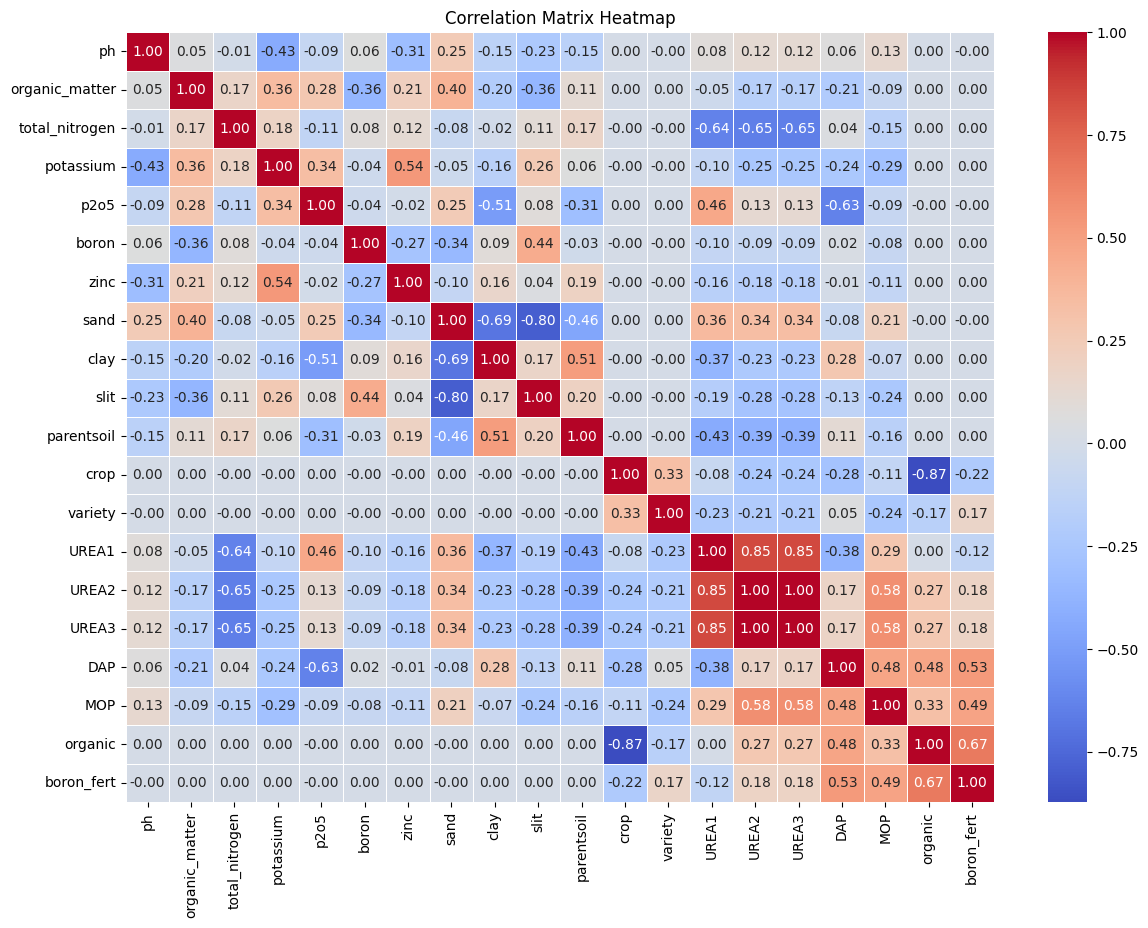

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is called df
correlation_matrix = df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()




Train Test SPlit

In [8]:
df.corr()

,ph,organic_matter,total_nitrogen,potassium,p2o5,boron,zinc,sand,clay,slit,parentsoil,crop,variety,UREA1,UREA2,UREA3,DAP,MOP,organic,boron_fert
ph,1.000000e+00,5.430679e-02,-1.362418e-02,-4.334582e-01,-9.167726e-02,5.744335e-02,-3.131010e-01,2.530552e-01,-1.480863e-01,-2.349843e-01,-1.496046e-01,9.386756e-16,-2.100898e-16,0.080448,0.121739,0.121739,0.064714,0.131881,2.501868e-16,-2.973134e-15
organic_matter,5.430679e-02,1.000000e+00,1.710882e-01,3.550376e-01,2.798724e-01,-3.608964e-01,2.110627e-01,4.031677e-01,-2.020265e-01,-3.624935e-01,1.100501e-01,2.805399e-16,4.478039e-16,-0.046035,-0.170665,-0.170665,-0.211403,-0.087103,1.054612e-16,1.272321e-15
total_nitrogen,-1.362418e-02,1.710882e-01,1.000000e+00,1.824768e-01,-1.139728e-01,7.925199e-02,1.173775e-01,-7.617077e-02,-2.413023e-02,1.052388e-01,1.697267e-01,-2.243934e-15,-1.910317e-15,-0.635050,-0.649192,-0.649192,0.044697,-0.151473,4.370319e-15,2.987041e-15
potassium,-4.334582e-01,3.550376e-01,1.824768e-01,1.000000e+00,3.396603e-01,-3.991316e-02,5.353838e-01,-5.032165e-02,-1.564553e-01,2.611734e-01,5.943618e-02,-9.518113e-16,-4.318495e-16,-0.103652,-0.247794,-0.247794,-0.241443,-0.292709,1.546104e-15,2.430697e-15
p2o5,-9.167726e-02,2.798724e-01,-1.139728e-01,3.396603e-01,1.000000e+00,-4.010293e-02,-1.609639e-02,2.537729e-01,-5.116012e-01,7.897309e-02,-3.064951e-01,3.289131e-15,2.253933e-15,0.461161,0.126068,0.126068,-0.633700,-0.085891,-5.891235e-15,-8.569039e-15
boron,5.744335e-02,-3.608964e-01,7.925199e-02,-3.991316e-02,-4.010293e-02,1.000000e+00,-2.704443e-01,-3.442467e-01,9.027755e-02,4.390115e-01,-2.525966e-02,-4.119493e-16,-2.979575e-16,-0.098618,-0.093228,-0.093228,0.019811,-0.082930,3.807790e-16,1.283831e-15
zinc,-3.131010e-01,2.110627e-01,1.173775e-01,5.353838e-01,-1.609639e-02,-2.704443e-01,1.000000e+00,-9.946845e-02,1.564956e-01,4.174140e-02,1.938385e-01,-1.932403e-15,-1.197186e-15,-0.164955,-0.178574,-0.178574,-0.006729,-0.106211,3.804236e-15,8.362868e-15
sand,2.530552e-01,4.031677e-01,-7.617077e-02,-5.032165e-02,2.537729e-01,-3.442467e-01,-9.946845e-02,1.000000e+00,-6.937432e-01,-7.977542e-01,-4.615623e-01,3.324444e-15,1.608758e-15,0.363283,0.339132,0.339132,-0.080788,0.205851,-4.440985e-15,-1.211934e-14
clay,-1.480863e-01,-2.020265e-01,-2.413023e-02,-1.564553e-01,-5.116012e-01,9.027755e-02,1.564956e-01,-6.937432e-01,1.000000e+00,1.706306e-01,5.123589e-01,-4.352524e-15,-1.495318e-15,-0.367999,-0.229867,-0.229867,0.280250,-0.069475,5.199737e-15,1.881235e-14
slit,-2.349843e-01,-3.624935e-01,1.052388e-01,2.611734e-01,7.897309e-02,4.390115e-01,4.174140e-02,-7.977542e-01,1.706306e-01,1.000000e+00,2.004379e-01,-1.384683e-15,-1.192752e-15,-0.190523,-0.275600,-0.275600,-0.128497,-0.240181,2.512460e-15,2.362295e-15


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Assuming `df` is your DataFrame and you have three target columns 'target1', 'target2', 'target3'

# 1. Split the data into features (X) and targets (y)
X = df[['ph', 'organic_matter','total_nitrogen', 'potassium', 'p2o5', 'boron','zinc',
        'sand', 'clay', 'slit', 'parentsoil','crop', 'variety']]  # Features
y = df[['UREA1', 'UREA2', 'UREA3', 'DAP', 'MOP', 'boron_fert']]  # Multiple target variables

# 2. Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

X_train['organic_matter'] = np.log1p(X_train['organic_matter'])  # log(1 + x) to handle zeros
X_train['total_nitrogen'] = np.log1p(X_train['total_nitrogen'])
X_train['p2o5'] = np.log1p(X_train['p2o5'])
X_train['sand'] = np.log1p(X_train['sand'])


# Apply the same log transformation to the test data (using the same logic)
X_test['organic_matter'] = np.log1p(X_test['organic_matter'])
X_test['total_nitrogen'] = np.log1p(X_test['total_nitrogen'])
X_test['p2o5'] = np.log1p(X_test['p2o5'])
X_test['sand'] = np.log1p(X_test['sand'])


# Initialize the scaler
scaler = StandardScaler()

# Apply scaling to columns with mild skewness in the training data
X_train[['potassium', 'zinc', 'slit']] = scaler.fit_transform(
    X_train[['potassium', 'zinc', 'slit']]
)

# Apply scaling to the test data using the same scaler
X_test[['potassium', 'zinc', 'slit']] = scaler.transform(
    X_test[['potassium', 'zinc', 'slit']]
)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
import joblib


# 3. Preprocessing (log transform + scaling — keep same as before if needed)

# 4. Define LightGBM base model
lgb_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# 5. MultiOutput Wrapper
multi_lgb = MultiOutputRegressor(lgb_model)

# 6. Train Model
multi_lgb.fit(X_train, y_train)




MultiOutputRegressor(estimator=LGBMRegressor(learning_rate=0.05, max_depth=7,
                                             n_estimators=200, n_jobs=-1,
                                             random_state=42, verbose=-1))

In [29]:
# 7. Save the trained model
joblib.dump(multi_lgb, 'resource_allocation/model_lightbgm/lightgbm_multioutput_model.pkl')

['resource_allocation/model_lightbgm/lightgbm_multioutput_model.pkl']

In [22]:
import joblib

# Save the fitted StandardScaler
joblib.dump(scaler, 'resource_allocation/model_rf/trained_scaler.pkl')
print("Scaler saved as 'trained_scaler.pkl'")


Scaler saved as 'trained_scaler.pkl'


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on test set
y_pred = multi_lgb.predict(X_test)

# Initialize metrics storage
mae_scores = []
rmse_scores = []
r2_scores = []

# Loop over each output target
for i, col in enumerate(y.columns):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"Target: {col}")
    print(f" - MAE : {mae:.4f}")
    print(f" - RMSE: {rmse:.4f}")
    print(f" - R²  : {r2:.4f}\n")

# Optional: Mean summary changes tp .10f after decimal after ....
print("Average across all targets:")
print(f" - MAE : {np.mean(mae_scores):.10f}")
print(f" - RMSE: {np.mean(rmse_scores):.10f}")
print(f" - R²  : {np.mean(r2_scores):.10f}")


Target: UREA1
 - MAE : 0.0767
 - RMSE: 0.1497
 - R²  : 0.9637

Target: UREA2
 - MAE : 0.0711
 - RMSE: 0.1559
 - R²  : 0.9555

Target: UREA3
 - MAE : 0.0711
 - RMSE: 0.1559
 - R²  : 0.9555

Target: DAP
 - MAE : 0.0347
 - RMSE: 0.1081
 - R²  : 0.9902

Target: MOP
 - MAE : 0.0386
 - RMSE: 0.1372
 - R²  : 0.9588

Target: boron_fert
 - MAE : 0.0000
 - RMSE: 0.0000
 - R²  : 1.0000

Average across all targets:
 - MAE : 0.0487
 - RMSE: 0.1178
 - R²  : 0.9706


In [39]:
import joblib

# Save trained multi-output LightGBM model
joblib.dump(multi_lgb, 'resource_allocation/model_lightbgm/multi__lgb_model.pkl')

# Save the fitted scaler (if used)
joblib.dump(scaler, 'resource_allocation/model_lightbgm/feature_scaler.pkl')


['resource_allocation/model_lightbgm/feature_scaler.pkl']

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error: 0.30
R² Score: 0.54


In [14]:
# Predict for one sample (e.g., the first test instance)
single_pred = rf.predict([X_test.iloc[0]])
print("Prediction for 1st test sample:", single_pred)


Prediction for 1st test sample: [[2.14742048 3.14741238 3.14741238 2.76837805 2.85468074]]


c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor wa

In [34]:
import pandas as pd
import numpy as np

# ---- Custom input with correct column order ----
custom_input = pd.DataFrame([{
    'ph': 6.5,
    'organic_matter': 2.5,
    
    'total_nitrogen': 0.3,
    'potassium': 10,
    'p2o5': 25,
    'zinc': 1.2,
    'boron': 1.2,
    'sand': 45,
    'clay': 20,
    'slit': 35,
    'parentsoil' : 1,
    'crop' : 2,
    'variety' : 1,
    
}])[['ph', 'organic_matter', 'total_nitrogen', 'potassium', 'p2o5', 'boron','zinc','sand', 'clay', 'slit', 'parentsoil','crop','variety']]

# ---- Log transformations ----
custom_input['organic_matter'] = np.log1p(custom_input['organic_matter'])
custom_input['total_nitrogen'] = np.log1p(custom_input['total_nitrogen'])
custom_input['p2o5'] = np.log1p(custom_input['p2o5'])
custom_input['sand'] = np.log1p(custom_input['sand'])
custom_input['zinc'] = np.log1p(custom_input['zinc'])

# ---- Apply same scaler to selected columns ----
custom_input[['potassium', 'zinc', 'slit']] = scaler.transform(
    custom_input[['potassium', 'zinc', 'slit']]
)

# Load the saved model
loaded_model = joblib.load('resource_allocation/model_lightbgm/lightgbm_multioutput_model.pkl')

# Predict on custom input (must match features & preprocessing)
preds = loaded_model.predict(custom_input)
print(preds)



[[-0.67214902  0.6504429   0.6504429   3.62443866  2.81097328  1.49999299]]


In [ ]:
joblib.dump(scaler, 'trained_scaler.pkl')
print("Scaler saved to 'trained_scaler.pkl'")